In [17]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, HTML

In [18]:
import scanpy as sc
import pandas as pd
import numpy as np

adata = sc.read_10x_mtx(
    "../../data/peripheral_blood_mononuclear_cells_10x_genomics/filtered_feature_bc_matrix/",
    var_names='gene_symbols',
    cache=True
)

adata

AnnData object with n_obs × n_vars = 11769 × 33538
    var: 'gene_ids', 'feature_types'

In [19]:
data_path = os.path.join("..","..", "data")
glioblastoma_norm_file = os.path.join(data_path, "glioblastoma_normalized.h5ad")
glioblastoma_raw_file = os.path.join(data_path, "glioblastoma_raw.h5ad")
pbmc3k_file = os.path.join(data_path, "pbmc3k.h5ad")

adata_glioblastoma_norm = sc.read_h5ad(glioblastoma_norm_file)
adata_glioblastoma_raw = sc.read_h5ad(glioblastoma_raw_file)
adata_pbmc3k = sc.read_h5ad(pbmc3k_file)

c:\Users\labsy\Desktop\GraphAttnVAE-scRNA\autoenc_env\Lib\site-packages\anndata\_io\h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
c:\Users\labsy\Desktop\GraphAttnVAE-scRNA\autoenc_env\Lib\site-packages\anndata\_io\h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


## Dataset: pbmc3k
This dataset contains information about gene expression in peripheral blood mononuclear cells (PBMC). Each row represents a gene, and the columns contain statistics about its expression across different cells.


### 🔍 Variables in the dataset

| **Variable**             | **Description** |
|------------------------|-------------|
| `gene_ids`        | Unique gene identifier in Ensembl format (`ENSGxxxxxxxxxxx`). |
| `n_cells_by_counts` | Number of cells in which the gene was detected. |
| `mean_counts`      | Mean expression value of the gene across all cells. |
| `log1p_mean_counts` | Log-transformed (`log1p`) mean expression of the gene. |
| `pct_dropout_by_counts` | Percentage of cells where the gene was not expressed (`dropout`). |
| `total_counts`     | Total sum of expression values for the gene across all cells. |
| `log1p_total_counts` | Log-transformed (`log1p`) total expression count. |
| `n_cells`         | Total number of cells in which gene expression was measured. |
| `highly_variable` | Indicates whether the gene is highly variable (`True/False`), useful for feature selection. |
| `means`          | Mean gene expression in the sample, without log transformation. |
| `dispersions`     | Dispersion of the gene expression across all cells. |
| `dispersions_norm` | Normalized dispersion of the gene, adjusted by the mean. |

### HEAD of data observed

| index              | n_genes_by_counts | log1p_n_genes_by_counts | total_counts | log1p_total_counts | pct_counts_in_top_50_genes | pct_counts_in_top_100_genes | pct_counts_in_top_200_genes |
|-------------------|-------------------|--------------------------|--------------|--------------------|-----------------------------|------------------------------|------------------------------|
| AAACATACACACCAC-1 | 781               | 6.661855                 | 2421.0       | 7.792349           | 47.748864                   | 63.279637                    | 74.969021                    |
| AAACATTGAGCTAC-1  | 1352              | 7.210080                 | 4903.0       | 8.497807           | 45.502753                   | 61.023863                    | 71.813176                    |
| AAACATTGATCAGC-1  | 1131              | 7.031741                 | 3149.0       | 8.055158           | 41.314703                   | 53.794856                    | 65.449349                    |
| AAACCGTGCTTCCG-1  | 960               | 6.867974                 | 2639.0       | 7.878534           | 39.029936                   | 52.898825                    | 66.691929                    |
| AAACCGTGTATGCG-1  | 522               | 6.259581                 | 981.0        | 6.889591           | 44.852192                   | 55.657492                    | 67.176351                    |

## Dataset: periphereal blood mononuclear cells 10x genomics
### 🔍 Variables in the dataset

| **Variable**                     | **Description** |
|--------------------------------|----------------|
| n_genes                        | Number of genes detected per cell (non-zero counts). |
| total_counts                   | Total expression counts per cell (library size). |
| n_genes_by_counts              | Number of genes with at least one count in the cell. |
| log1p_n_genes_by_counts        | Log-transformed (log1p) number of detected genes per cell. |
| log1p_total_counts             | Log-transformed (log1p) total counts per cell. |
| pct_counts_in_top_50_genes     | Percentage of counts coming from the top 50 most expressed genes in the cell. |
| pct_counts_in_top_100_genes    | Percentage of counts coming from the top 100 most expressed genes in the cell. |
| pct_counts_in_top_200_genes    | Percentage of counts coming from the top 200 most expressed genes in the cell. |
| pct_counts_in_top_500_genes    | Percentage of counts coming from the top 500 most expressed genes in the cell. |
| total_counts_mt                | Total counts from mitochondrial genes per cell. |
| log1p_total_counts_mt          | Log-transformed (log1p) mitochondrial counts per cell. |
| pct_counts_mt                  | Percentage of total counts derived from mitochondrial genes. |


In [20]:
adata.obs["n_genes"] = np.array((adata.X > 0).sum(axis=1)).flatten()
adata.obs["total_counts"] = np.array(adata.X.sum(axis=1)).flatten()

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

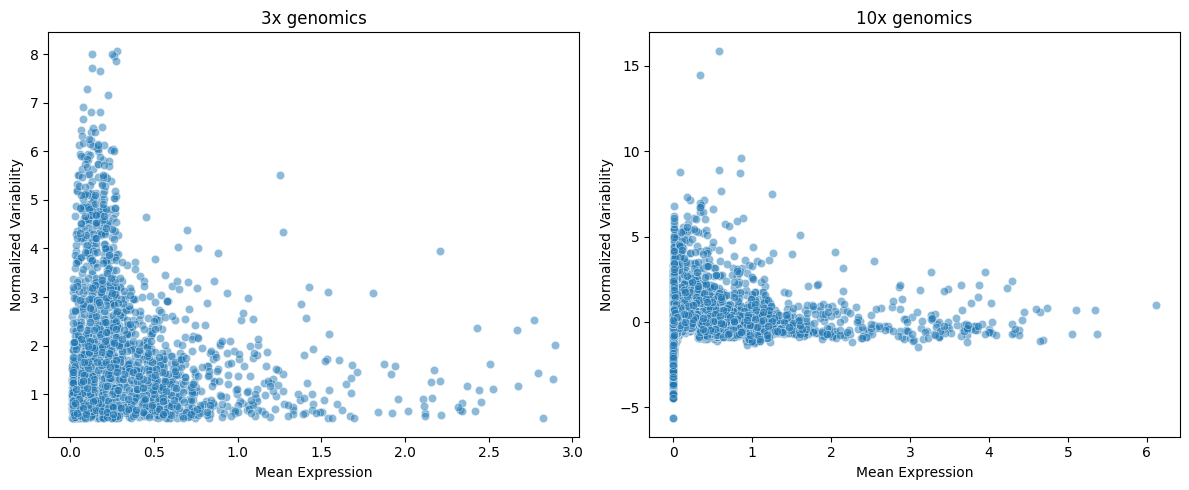

In [21]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
# Crear matriz de plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 → pbmc3k
sns.scatterplot(
    data=adata_pbmc3k.var,
    x="means",
    y="dispersions_norm",
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("3x genomics")
axes[0].set_xlabel("Mean Expression")
axes[0].set_ylabel("Normalized Variability")

# Plot 2 → tu dataset
sns.scatterplot(
    data=adata.var,
    x="means",
    y="dispersions_norm",
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("10x genomics")
axes[1].set_xlabel("Mean Expression")
axes[1].set_ylabel("Normalized Variability")

plt.tight_layout()
plt.show()

C:\Users\labsy\AppData\Local\Temp\ipykernel_28336\1668848463.py:3: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient. Try using != instead.
  np.array((adata.X == 0).sum(axis=0)).flatten() / adata.n_obs * 100
c:\Users\labsy\Desktop\GraphAttnVAE-scRNA\autoenc_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\labsy\Desktop\GraphAttnVAE-scRNA\autoenc_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


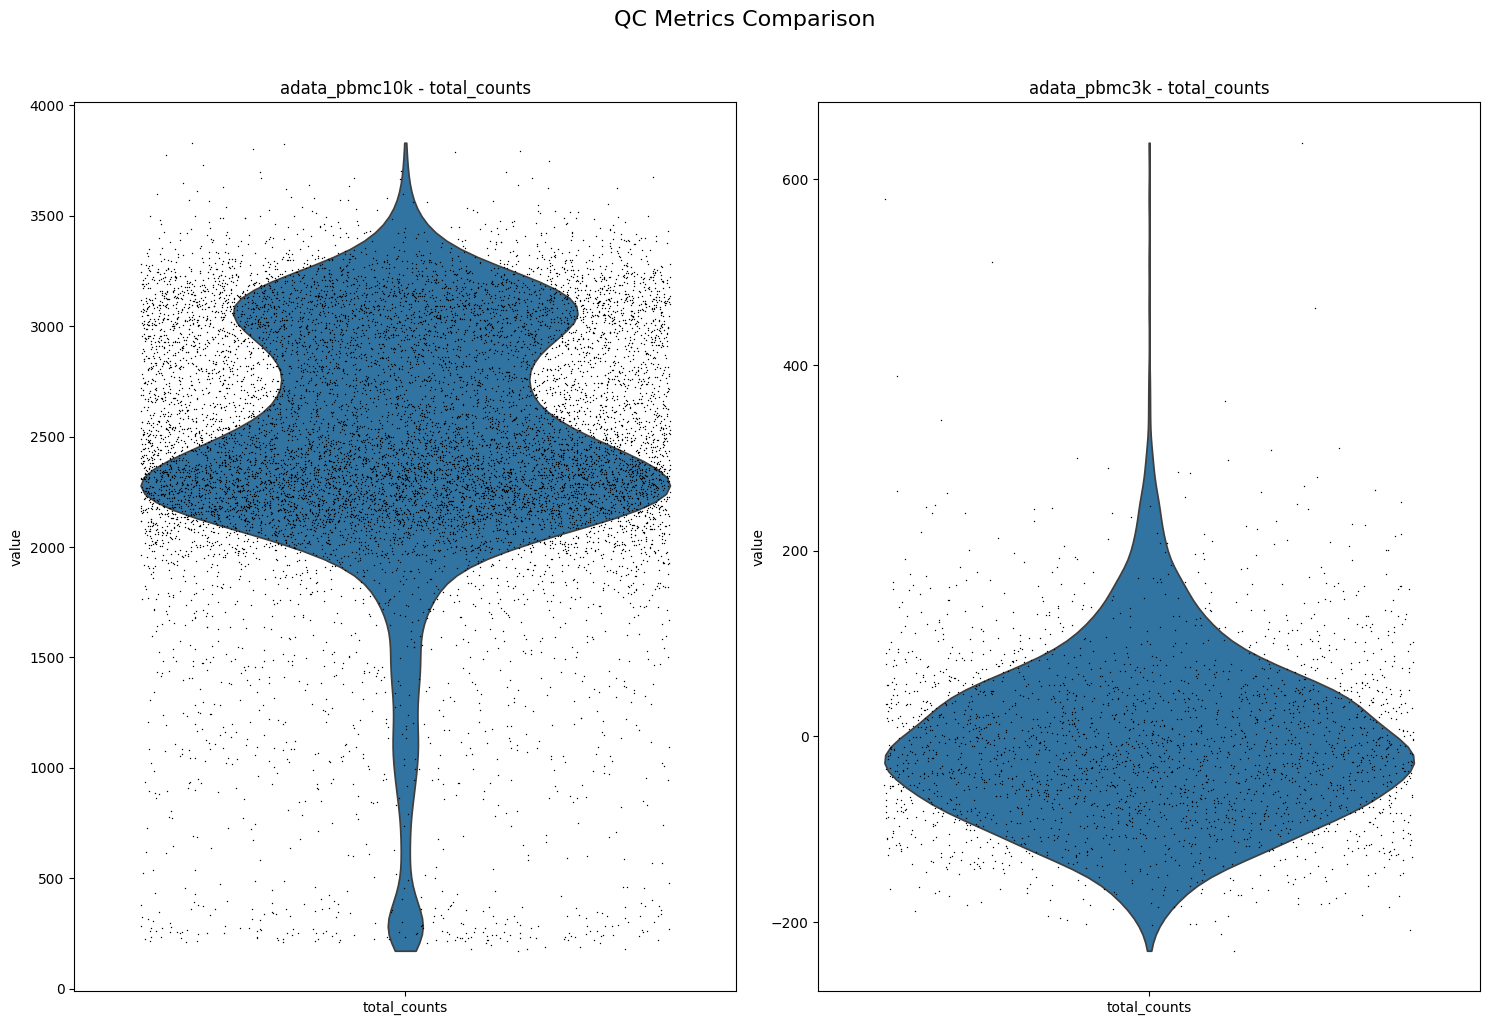

In [22]:
adata.var["mean_counts"] = np.array(adata.X.mean(axis=0)).flatten()
adata.var["pct_dropout_by_counts"] = (
    np.array((adata.X == 0).sum(axis=0)).flatten() / adata.n_obs * 100
)
adata.obs['n_genes'] = (adata.X > 0).sum(axis=1)
adata.obs['total_counts'] = adata.X.sum(axis=1)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata_pbmc3k.var['mt'] = adata_pbmc3k.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(
    adata_pbmc3k,
    qc_vars=['mt'],
    inplace=True
)
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

import matplotlib.pyplot as plt
import scanpy as sc

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

# --- Fila 1: adata ---
for i, var in enumerate([ 'total_counts']):
    sc.pl.violin(
        adata,
        var,
        jitter=0.4,
        ax=axes[0],
        show=False
    )
    axes[0].set_title(f'adata_pbmc10k - {var}')

# --- Fila 2: adata_pbmck3 ---
for i, var in enumerate([ 'total_counts']):
    sc.pl.violin(
        adata_pbmc3k,
        var,
        jitter=0.4,
        ax=axes[1],
        show=False
    )
    axes[1].set_title(f'adata_pbmc3k - {var}')

plt.suptitle('QC Metrics Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [23]:

adata_pbmc3k.var

,gene_ids,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm,mt
index,,,,,,,,,,,,,
TNFRSF4,ENSG00000186827,2638,1.521749e-08,1.521749e-08,0.0,0.000040,0.000040,155,True,0.277410,2.086050,0.665406,False
CPSF3L,ENSG00000127054,2638,-8.932424e-04,-8.936416e-04,0.0,-2.356374,NaN,202,True,0.385194,4.506988,2.955005,False
ATAD3C,ENSG00000215915,2638,-1.960645e-02,-1.980121e-02,0.0,-51.721828,NaN,9,True,0.038252,3.953486,4.352607,False
C1orf86,ENSG00000162585,2638,1.287894e-09,1.287894e-09,0.0,0.000003,0.000003,501,True,0.678283,2.713521,0.543182,False
RER1,ENSG00000157916,2638,-3.536060e-09,-3.536060e-09,0.0,-0.000009,-0.000009,608,True,0.814813,3.447533,1.582528,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICOSLG,ENSG00000160223,2638,-4.729880e-03,-4.741101e-03,0.0,-12.477423,NaN,34,True,0.082016,2.585818,1.652185,False
SUMO3,ENSG00000184900,2638,6.066659e-09,6.066659e-09,0.0,0.000016,0.000016,570,True,0.804815,4.046776,2.431044,False
SLC19A1,ENSG00000173638,2638,-6.943908e-03,-6.968129e-03,0.0,-18.318029,NaN,31,True,0.058960,3.234231,2.932459,False


## Cluster process on 10x Genomics dataset

In [24]:
# Chequea si ya fueron procesados
print(adata.X.min(), adata.X.max())
print(adata.raw)  # Si tiene .raw, ya fue procesado

0.0 8.862733
None


In [25]:
import scipy.sparse as sp

In [ ]:
if sp.issparse(adata.X):
    adata.X.data = np.nan_to_num(adata.X.data, nan=0.0)
else:
    adata.X = np.nan_to_num(adata.X, nan=0.0)

# 1. Filtrado básico
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# 2. Normalización y log-transformación
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 3. Genes altamente variables
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')
adata = adata[:, adata.var.highly_variable]

# 4. Escalar datos
sc.pp.scale(adata, max_value=10)

# 5. PCA
sc.tl.pca(adata, svd_solver='arpack')

# 6. Vecinos y UMAP
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

# 7. Clustering Leiden
sc.tl.leiden(adata, resolution=0.5)

C:\Users\labsy\anaconda3\Lib\functools.py:907: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\labsy\anaconda3\Lib\functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\labsy\AppData\Local\Temp\ipykernel_28336\1295986799.py:29: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


leiden
0     3097
1     1752
2     1180
3     1047
4      830
5      786
6      631
7      449
8      425
9      367
10     266
11     255
12     135
13     121
14      86
15      83
16      27
Name: count, dtype: int64


C:\Users\labsy\AppData\Local\Temp\ipykernel_28336\1771924308.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


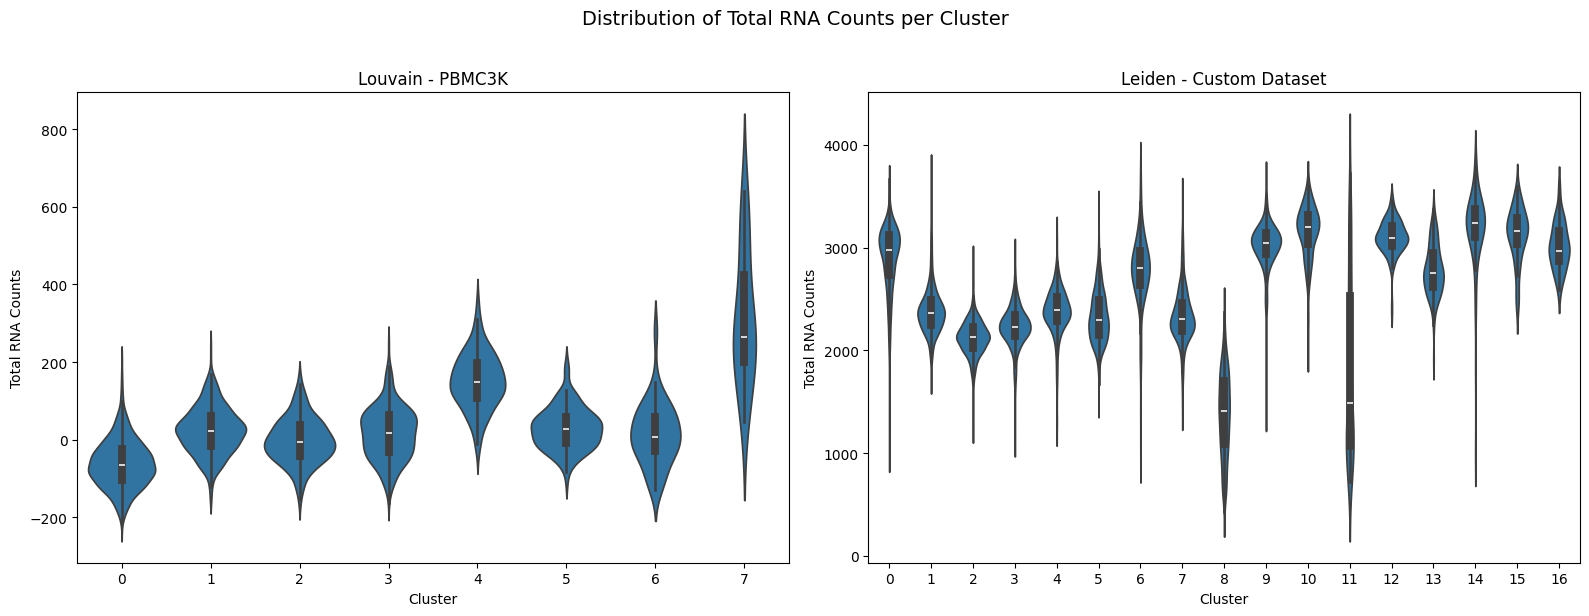

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=adata_pbmc3k.obs, x="louvain", y="total_counts", ax=axes[0])
axes[0].set_title("Louvain - PBMC3K")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Total RNA Counts")

sns.violinplot(data=adata.obs, x="leiden", y="total_counts", ax=axes[1])
axes[1].set_title("Leiden - Custom Dataset")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Total RNA Counts")

plt.suptitle("Distribution of Total RNA Counts per Cluster", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



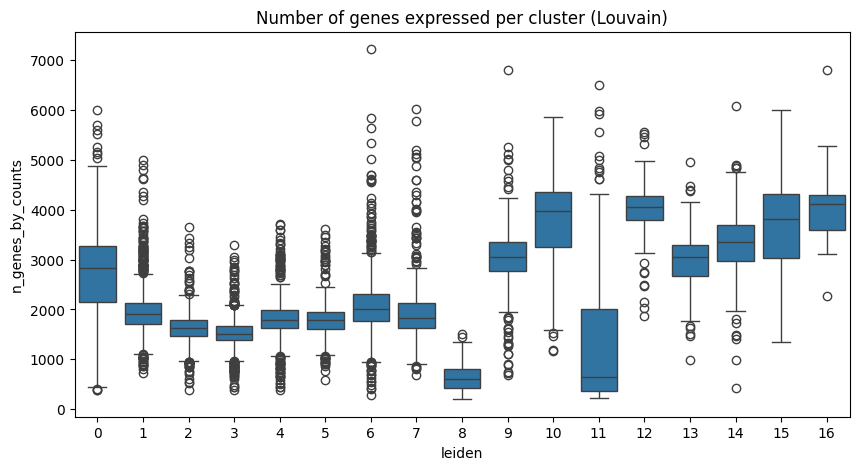

In [35]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="leiden", y="n_genes_by_counts", data=adata.obs)
plt.title("Number of genes expressed per cluster (Louvain)")
plt.show()


In [ ]:
# Corregir el zip (3 adatas, 3 nombres)
for adata, name in zip(
    [adata], 
    [ "PBMC 10k"]
):
    # Preprocesamiento mínimo si no se ha hecho
    if 'neighbors' not in adata.uns:
        sc.pp.neighbors(adata)
    if 'X_umap' not in adata.obsm:
        sc.tl.umap(adata)
    
    # Usar leiden/louvain si no hay cell_type anotado
    color_key = "cell_type" if "cell_type" in adata.obs.columns else "leiden"
    
    sc.pl.umap(adata, color=color_key, title=name)